# Lab 02: GAN for Images (MNIST)

**Goal:** Build a GAN that generates handwritten digit images from pure noise.

**What you'll do:**
- Load and explore the MNIST dataset
- Build a Generator that outputs 784 pixels (28x28 image)
- Build a Discriminator with LeakyReLU
- Train and watch images evolve from noise to digits
- Compare real vs fake images
- Experiment: interpolation in noise space, different noise sizes

**Time:** ~60 minutes

---

## Part 1: Setup

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## Part 2: Load and Explore MNIST

**What is MNIST?**
- 60,000 handwritten digit images (0-9)
- Each image: 28x28 pixels, grayscale
- We normalize to [-1, 1] to match Tanh output range

**Normalization formula:**
- ToTensor: pixel [0, 255] → [0, 1]
- Normalize([0.5], [0.5]): [0, 1] → [-1, 1]

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

images, labels = next(iter(dataloader))
print(f"Batch shape:     {images.shape}   (64 images, 1 channel, 28x28)")
print(f"One image shape: {images[0].shape}")
print(f"Pixel range:     [{images.min():.1f}, {images.max():.1f}]")
print(f"Labels:          {labels[:10].tolist()}")
print(f"\nTotal images: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

100.0%
100.0%
100.0%
100.0%

Batch shape:     torch.Size([64, 1, 28, 28])   (64 images, 1 channel, 28x28)
One image shape: torch.Size([1, 28, 28])
Pixel range:     [-1.0, 1.0]
Labels:          [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]

Total images: 60000
Batches per epoch: 938


**Let's see some real MNIST images:**
- These are what our GAN will learn to imitate
- Each one is 28x28 pixels

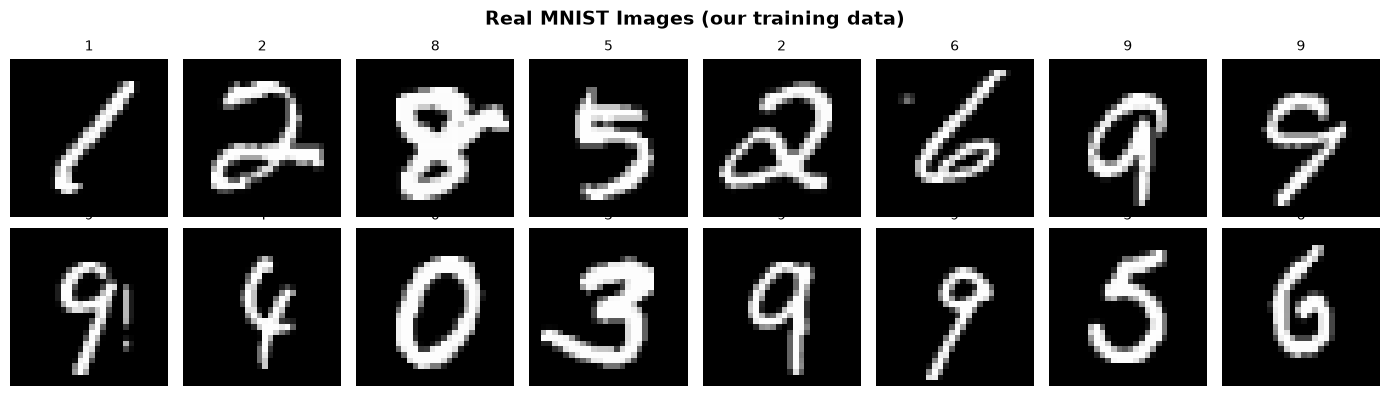

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap='gray')
    ax.set_title(f'{labels[i].item()}', fontsize=10)
    ax.axis('off')

plt.suptitle('Real MNIST Images (our training data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Build the Generator

**What it does:**
- Takes 64 random numbers (noise) and produces 784 pixel values (one image)
- Expands gradually: 64 → 256 → 512 → 784
- ReLU in hidden layers, Tanh at output (pixels in [-1, 1])

**Why these layer sizes?**
- Gradual expansion — each layer roughly doubles
- 256, 512 are enough for MNIST (simple images)
- Powers of 2 run faster on hardware

In [4]:
NOISE_SIZE = 64
IMAGE_SIZE = 784  # 28 * 28

generator = nn.Sequential(
    nn.Linear(NOISE_SIZE, 256),   # 64 → 256
    nn.ReLU(),
    nn.Linear(256, 512),          # 256 → 512
    nn.ReLU(),
    nn.Linear(512, IMAGE_SIZE),   # 512 → 784
    nn.Tanh()                     # pixels in [-1, 1]
).to(device)

print("Generator:")
print(generator)
print(f"\nParameters: {sum(p.numel() for p in generator.parameters()):,}")

Generator:
Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=784, bias=True)
  (5): Tanh()
)

Parameters: 550,416


**Test G before training:**
- Output should be random noise (G hasn't learned yet)
- Shape should be [1, 784] — one image worth of pixels

Noise shape:  torch.Size([1, 64])    (64 random numbers)
Output shape: torch.Size([1, 784])  (784 pixels = one image)
Output range: [-0.34, 0.36]  (Tanh gives [-1, 1])


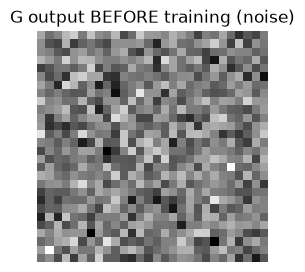

In [5]:
noise = torch.randn(1, NOISE_SIZE, device=device)
fake_image = generator(noise)

print(f"Noise shape:  {noise.shape}    (64 random numbers)")
print(f"Output shape: {fake_image.shape}  (784 pixels = one image)")
print(f"Output range: [{fake_image.min():.2f}, {fake_image.max():.2f}]  (Tanh gives [-1, 1])")

plt.figure(figsize=(3, 3))
plt.imshow(fake_image.detach().cpu().view(28, 28), cmap='gray')
plt.title('G output BEFORE training (noise)')
plt.axis('off')
plt.show()

---
## Part 4: Build the Discriminator

**What it does:**
- Takes 784 pixel values (one image) and outputs a probability (real or fake)
- Compresses gradually: 784 → 512 → 256 → 1
- LeakyReLU(0.2) in hidden layers — lets 20% of negatives through (keeps gradients alive)
- Sigmoid at output — squashes to [0, 1] probability

**Why LeakyReLU instead of ReLU?**
- ReLU blocks all negatives → gradient = 0 → neuron dies
- LeakyReLU lets 20% through → gradient = 0.2 → neuron stays alive
- D needs every neuron alive to judge well

In [6]:
discriminator = nn.Sequential(
    nn.Linear(IMAGE_SIZE, 512),   # 784 → 512
    nn.LeakyReLU(0.2),            # 20% of negatives pass through
    nn.Linear(512, 256),          # 512 → 256
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),            # 256 → 1
    nn.Sigmoid()                   # probability [0, 1]
).to(device)

print("Discriminator:")
print(discriminator)
print(f"\nParameters: {sum(p.numel() for p in discriminator.parameters()):,}")

Discriminator:
Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

Parameters: 533,505


**The mirror shape:**
```
G:  64 → 256 → 512 → 784   (small → big, CREATES)
D: 784 → 512 → 256 →  1    (big → small, JUDGES)
```

---
## Part 5: Loss, Optimizers, and Helper

**Same as L02:**
- BCE Loss (real or fake classification)
- Adam optimizer for both G and D
- lr=0.0002 (smaller than L02's 0.001 — images need more stability)

In [7]:
loss_fn = nn.BCELoss()
gen_opt = torch.optim.Adam(generator.parameters(), lr=0.0002)
dis_opt = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

print("Loss:      BCELoss")
print("Optimizer: Adam (lr=0.0002)")
print("Batch:     64 images")

Loss:      BCELoss
Optimizer: Adam (lr=0.0002)
Batch:     64 images


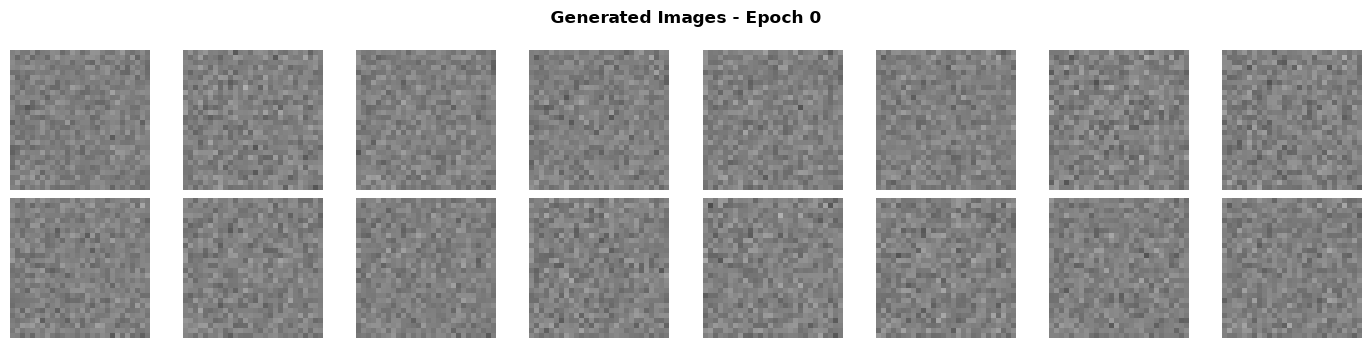

In [14]:
def show_images(generator, epoch, num=16):
    """Generate and display a grid of images."""
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num, NOISE_SIZE, device=device)
        imgs = generator(noise).cpu().view(-1, 28, 28)
    generator.train()

    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i], cmap='gray', vmin=-1, vmax=1)
        ax.axis('off')
    plt.suptitle(f'Generated Images - Epoch {epoch}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test: show untrained G output
show_images(generator, epoch=0)

---
## Part 6: Train the GAN

**Same two-step loop as Lab 01, now with batches of images:**

**Step A — Train D:**
- D sees real images (from MNIST) → should say 1
- D sees fake images (from G) → should say 0
- `.detach()` on fakes so only D learns
- Flatten images from 28x28 to 784 for Linear layers

**Step B — Train G:**
- G creates fake images from noise
- G wants D to say 1 (fooled!)
- No `.detach()` — G learns from D's feedback

**What to watch:**
- Images should go from random noise → blurry blobs → recognizable digits
- Losses should stay in similar range

Training for 50 epochs...
Dataset: 60000 images, 938 batches per epoch

Epoch  1: D_loss=0.1659  G_loss=5.1395


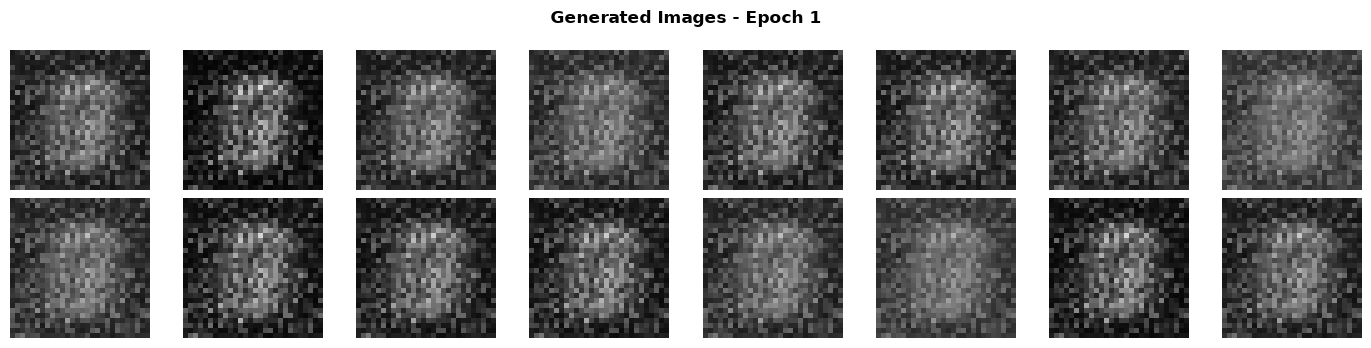


Epoch  5: D_loss=0.0737  G_loss=7.5538


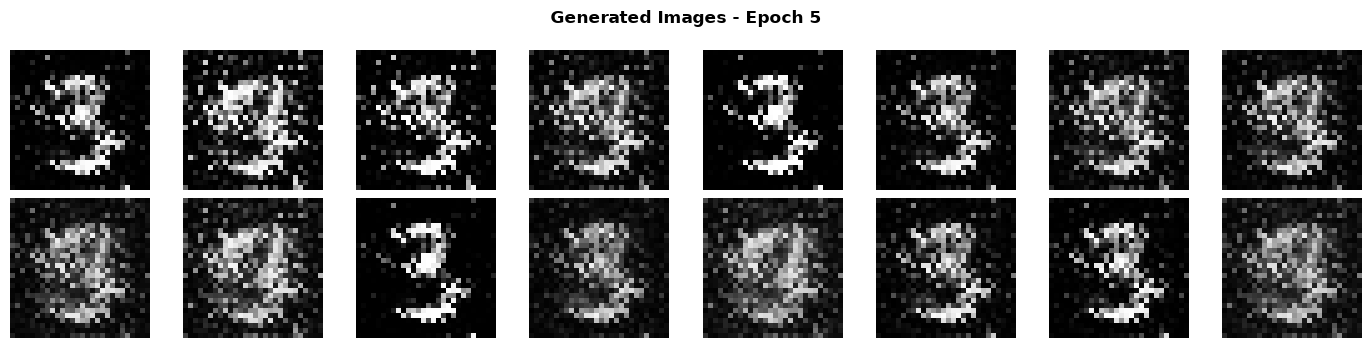


Epoch 10: D_loss=0.1928  G_loss=5.9345


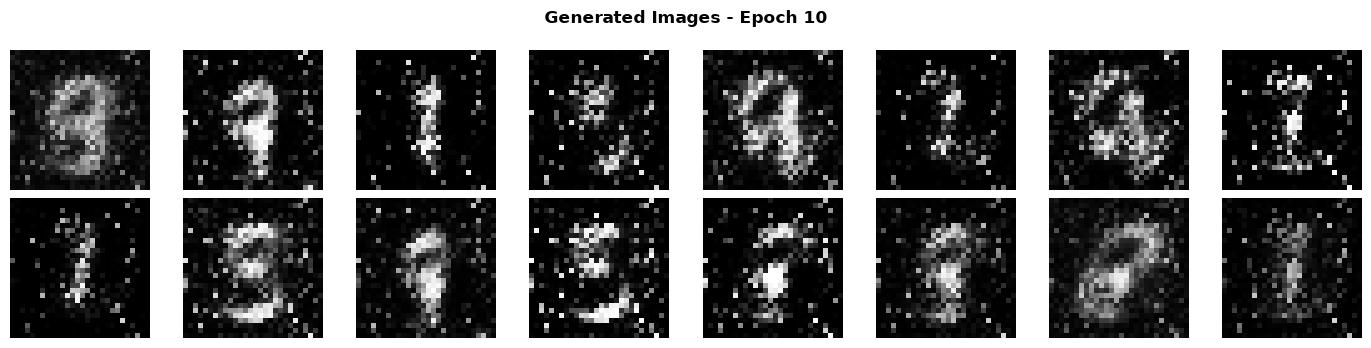


Epoch 20: D_loss=0.3121  G_loss=4.5157


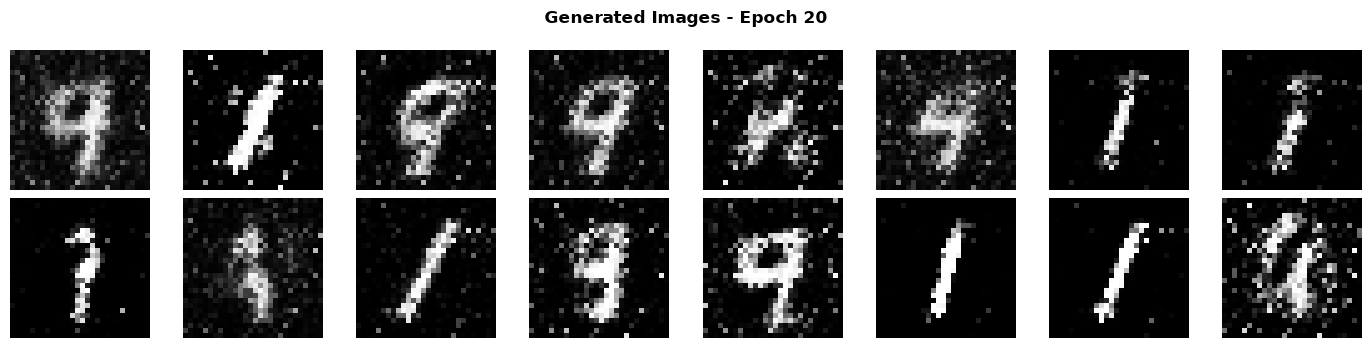


Epoch 30: D_loss=0.6104  G_loss=2.5108


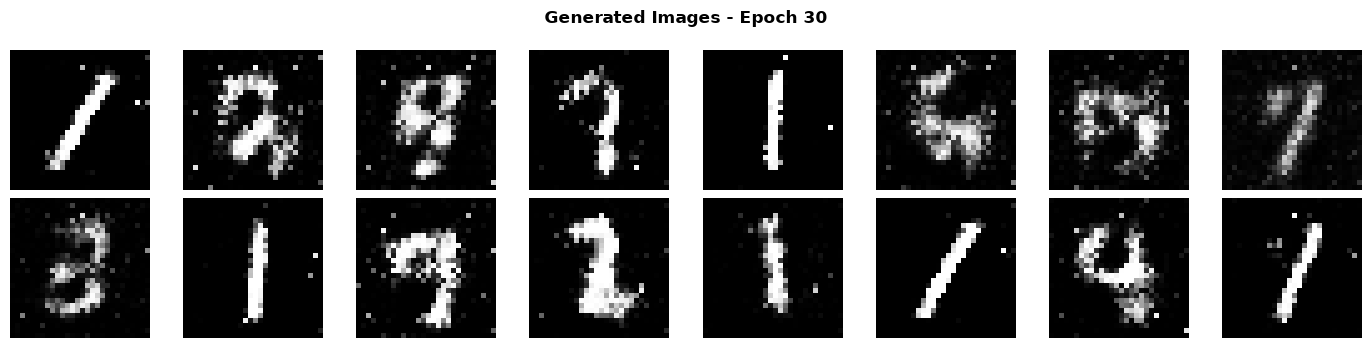


Epoch 40: D_loss=0.6504  G_loss=2.4417


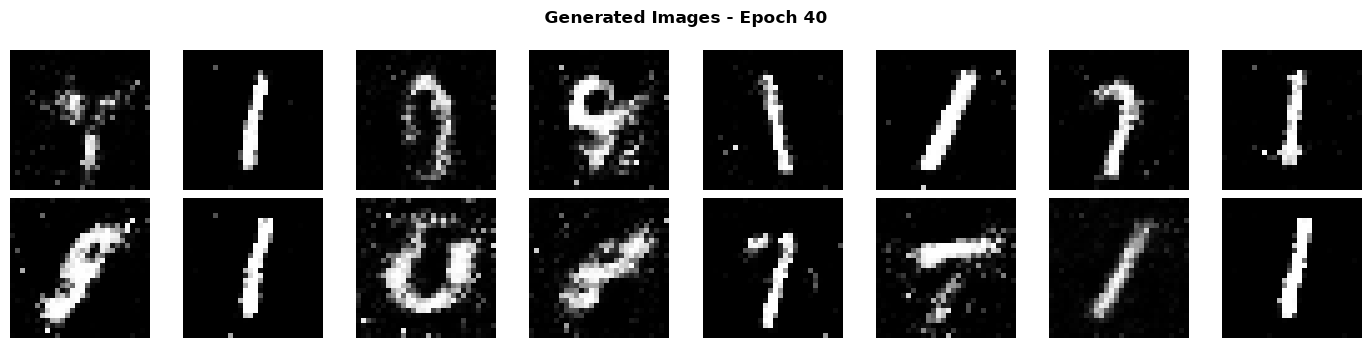


Epoch 50: D_loss=0.7655  G_loss=2.0228


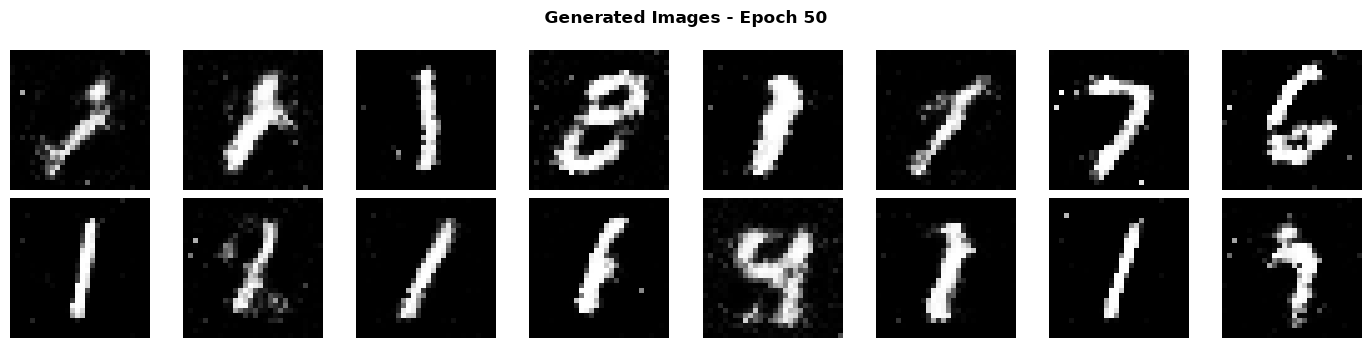


Training complete!


In [15]:
num_epochs = 50
gen_losses = []
dis_losses = []

print(f"Training for {num_epochs} epochs...")
print(f"Dataset: {len(dataset)} images, {len(dataloader)} batches per epoch")
print("=" * 60)

for epoch in range(1, num_epochs + 1):
    epoch_g, epoch_d = 0, 0
    num_batches = 0

    for real_images, _ in dataloader:
        batch_size = real_images.size(0)
        real_flat = real_images.view(batch_size, -1).to(device)  # flatten 28x28 → 784

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # ====== Step A: Train D ======
        real_pred = discriminator(real_flat)
        loss_real = loss_fn(real_pred, real_labels)

        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = generator(noise).detach()      # .detach() = only D learns
        fake_pred = discriminator(fake_images)
        loss_fake = loss_fn(fake_pred, fake_labels)

        dis_loss = loss_real + loss_fake
        dis_opt.zero_grad()
        dis_loss.backward()
        dis_opt.step()

        # ====== Step B: Train G ======
        noise = torch.randn(batch_size, NOISE_SIZE, device=device)
        fake_images = generator(noise)               # no detach = G learns
        fake_pred = discriminator(fake_images)
        gen_loss = loss_fn(fake_pred, real_labels)    # G wants D to say "real"

        gen_opt.zero_grad()
        gen_loss.backward()
        gen_opt.step()

        epoch_g += gen_loss.item()
        epoch_d += dis_loss.item()
        num_batches += 1

    avg_g = epoch_g / num_batches
    avg_d = epoch_d / num_batches
    gen_losses.append(avg_g)
    dis_losses.append(avg_d)

    if epoch in [1, 5, 10, 20, 30, 40, 50]:
        print(f"\nEpoch {epoch:2d}: D_loss={avg_d:.4f}  G_loss={avg_g:.4f}")
        show_images(generator, epoch)

print("\nTraining complete!")

---
## Part 7: Training Analysis

**Loss curves — are G and D balanced?**
- Both should stay in similar range
- If D drops to 0: D is too strong, G can't learn
- If G stays flat: G is stuck

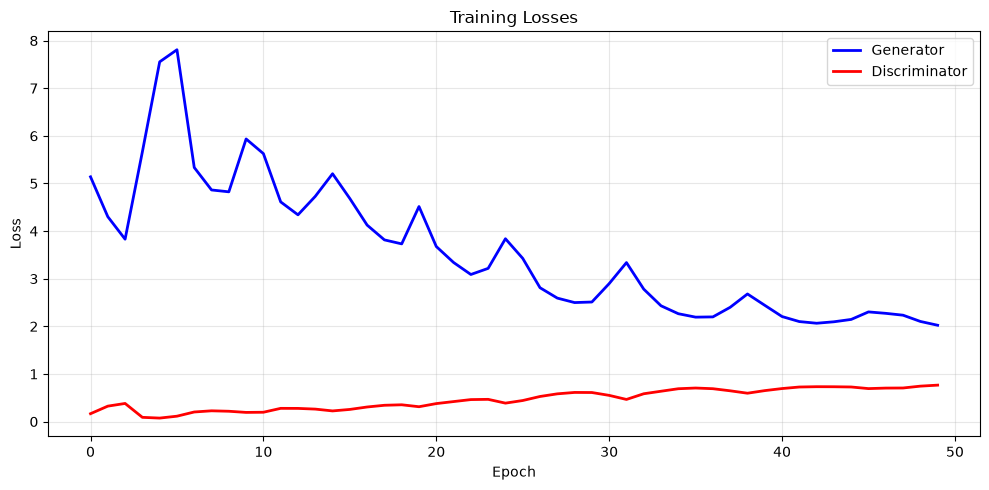

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gen_losses, label='Generator', color='blue', linewidth=2)
ax.plot(dis_losses, label='Discriminator', color='red', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Losses')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 8: Real vs Fake — Side by Side

**Top row:** real MNIST images  
**Bottom row:** G's fakes  
**Notice:** fakes are recognizable but **blurry** — that's the Linear layer limitation

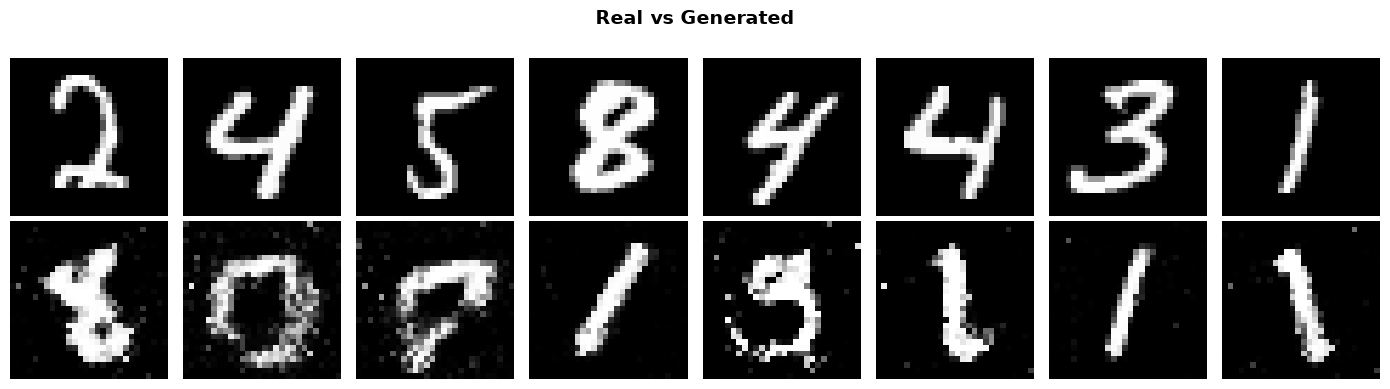

Fakes are recognizable but BLURRY.
Linear layers don't understand spatial structure.
DCGAN (Lab 03) fixes this with convolutional layers.


In [17]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Top: real images
real_batch = next(iter(dataloader))[0]
for i in range(8):
    axes[0, i].imshow(real_batch[i, 0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('REAL', fontsize=12, fontweight='bold',
                              rotation=0, labelpad=40)

# Bottom: fake images
generator.eval()
with torch.no_grad():
    fakes = generator(torch.randn(8, NOISE_SIZE, device=device)).cpu().view(-1, 28, 28)
for i in range(8):
    axes[1, i].imshow(fakes[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('FAKE', fontsize=12, fontweight='bold',
                              rotation=0, labelpad=40)

plt.suptitle('Real vs Generated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Fakes are recognizable but BLURRY.")
print("Linear layers don't understand spatial structure.")
print("DCGAN (Lab 03) fixes this with convolutional layers.")

---
## Part 9: Big Grid of Fakes

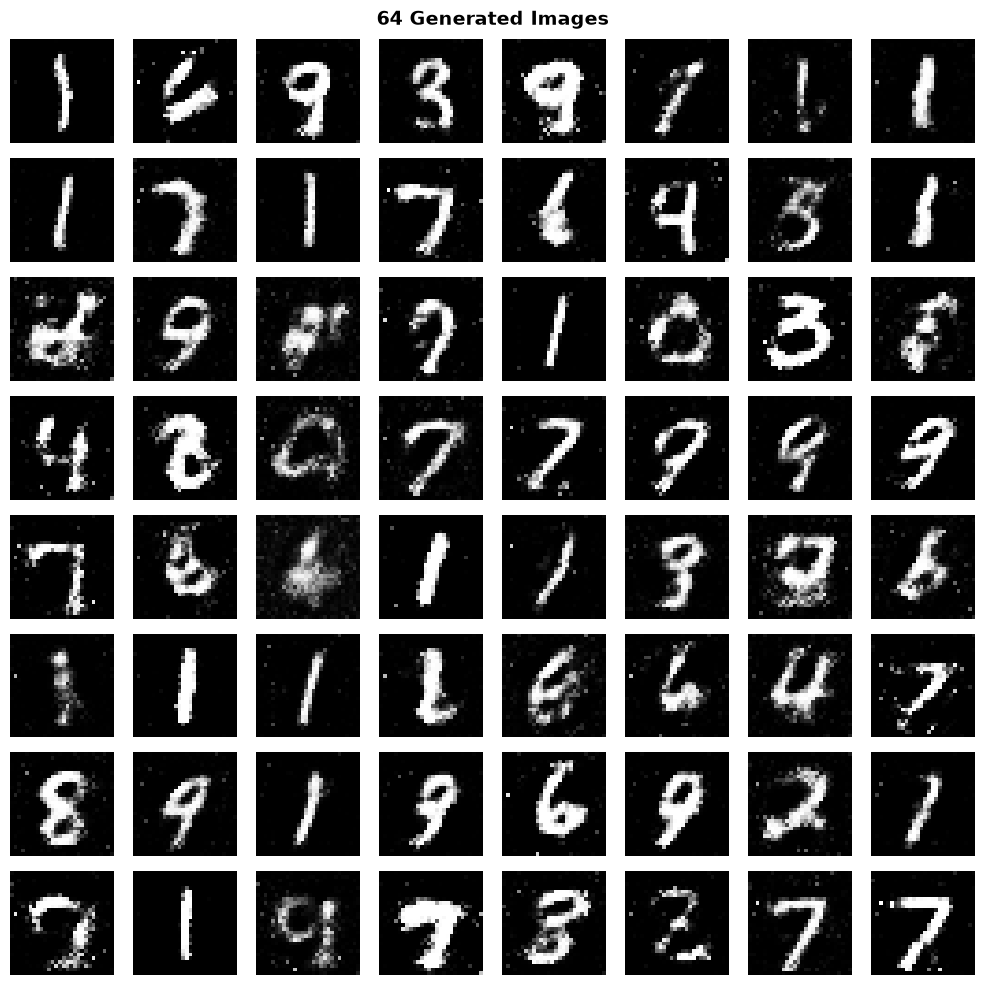

In [18]:
with torch.no_grad():
    noise = torch.randn(64, NOISE_SIZE, device=device)
    generated = generator(noise).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')

plt.suptitle('64 Generated Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 10: What D Thinks

**Ask D to score real and fake images:**
- D scores near 1.0 = thinks it's real
- D scores near 0.0 = thinks it's fake
- D scores near 0.5 = can't tell (G has fooled it)

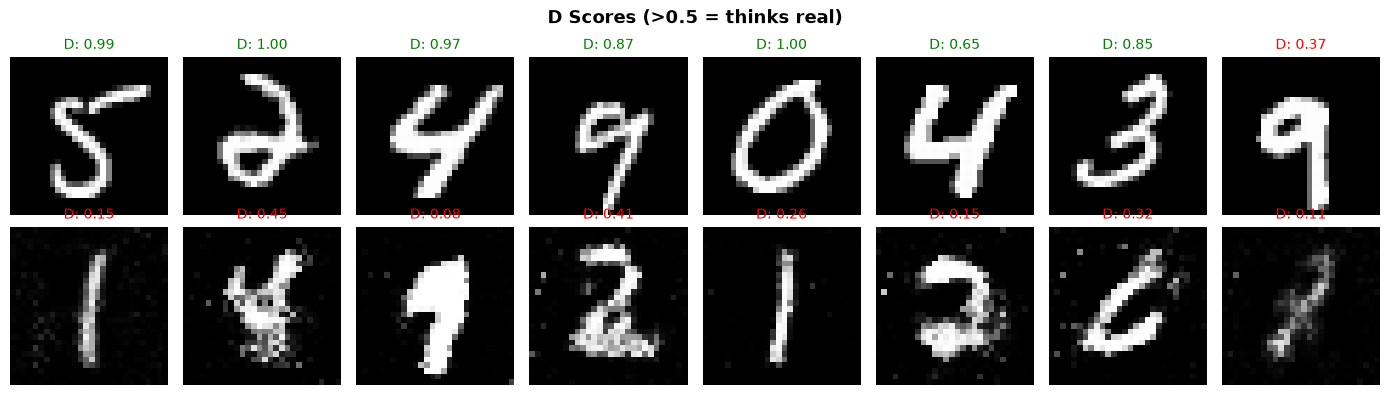

Avg D on real: 0.8374
Avg D on fake: 0.2408


In [19]:
discriminator.eval()

with torch.no_grad():
    # Real images
    real_batch = next(iter(dataloader))[0][:8]
    real_flat = real_batch.view(8, -1).to(device)
    real_scores = discriminator(real_flat).cpu().squeeze()

    # Fake images
    noise = torch.randn(8, NOISE_SIZE, device=device)
    fake_batch = generator(noise)
    fake_scores = discriminator(fake_batch).cpu().squeeze()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    axes[0, i].imshow(real_batch[i, 0], cmap='gray')
    axes[0, i].set_title(f'D: {real_scores[i]:.2f}', fontsize=10,
                         color='green' if real_scores[i] > 0.5 else 'red')
    axes[0, i].axis('off')

    axes[1, i].imshow(fake_batch[i].cpu().view(28, 28), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title(f'D: {fake_scores[i]:.2f}', fontsize=10,
                         color='green' if fake_scores[i] > 0.5 else 'red')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('REAL', fontsize=11, fontweight='bold', rotation=0, labelpad=40)
axes[1, 0].set_ylabel('FAKE', fontsize=11, fontweight='bold', rotation=0, labelpad=40)
plt.suptitle('D Scores (>0.5 = thinks real)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Avg D on real: {real_scores.mean():.4f}")
print(f"Avg D on fake: {fake_scores.mean():.4f}")

---
## Part 11: Experiments

### Experiment 1: Interpolation in Noise Space

**What happens when we smoothly move from one noise to another?**
- Pick two random noise vectors (z1 and z2)
- Gradually blend between them: 0% z1 → 100% z2
- If G learned well, images should morph smoothly

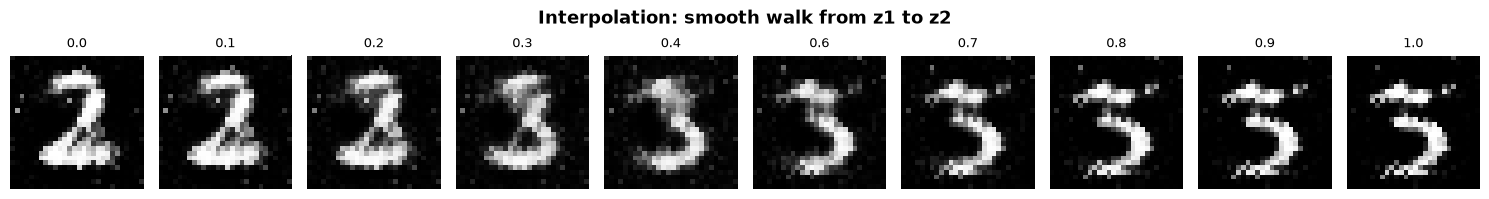

Smooth transitions = G learned a structured mapping from noise to images.
Nearby noise points → similar images. This is the 'latent space'.


In [20]:
generator.eval()

with torch.no_grad():
    z1 = torch.randn(1, NOISE_SIZE, device=device)
    z2 = torch.randn(1, NOISE_SIZE, device=device)

    steps = 10
    fig, axes = plt.subplots(1, steps, figsize=(15, 2))

    for i, ax in enumerate(axes):
        alpha = i / (steps - 1)               # 0.0 to 1.0
        z = (1 - alpha) * z1 + alpha * z2     # blend between z1 and z2
        img = generator(z).cpu().view(28, 28)
        ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'{alpha:.1f}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Interpolation: smooth walk from z1 to z2', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Smooth transitions = G learned a structured mapping from noise to images.")
print("Nearby noise points → similar images. This is the 'latent space'.")

### Experiment 2: Effect of Noise Size

**What if we use 2 noise numbers instead of 64?**
- Fewer noise numbers = less variety
- Too few → mode collapse (all outputs look the same)
- Too many → harder to train, diminishing returns

In [ ]:
def quick_train(noise_size, epochs=15):
    G = nn.Sequential(
        nn.Linear(noise_size, 256), nn.ReLU(),
        nn.Linear(256, 512), nn.ReLU(),
        nn.Linear(512, 784), nn.Tanh()
    ).to(device)
    D = nn.Sequential(
        nn.Linear(784, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 1), nn.Sigmoid()
    ).to(device)

    g_opt = torch.optim.Adam(G.parameters(), lr=0.0002)
    d_opt = torch.optim.Adam(D.parameters(), lr=0.0002)

    for epoch in range(1, epochs + 1):
        for real_imgs, _ in dataloader:
            bs = real_imgs.size(0)
            real = real_imgs.view(bs, -1).to(device)
            ones = torch.ones(bs, 1, device=device)
            zeros = torch.zeros(bs, 1, device=device)

            d_loss = loss_fn(D(real), ones) + \
                     loss_fn(D(G(torch.randn(bs, noise_size, device=device)).detach()), zeros)
            d_opt.zero_grad(); d_loss.backward(); d_opt.step()

            g_loss = loss_fn(D(G(torch.randn(bs, noise_size, device=device))), ones)
            g_opt.zero_grad(); g_loss.backward(); g_opt.step()
    return G

noise_sizes = [2, 16, 64, 256]
trained = {}
for ns in noise_sizes:
    print(f"Training with noise_size={ns}...")
    trained[ns] = quick_train(ns)
print("Done!")

Training with noise_size=2...


**Compare outputs for different noise sizes:**
- z=2: very limited variety (possible mode collapse)
- z=64: good balance of variety and quality
- z=256: more variety but harder to train

In [ ]:
fig, axes = plt.subplots(len(noise_sizes), 8, figsize=(14, 2 * len(noise_sizes)))

for row, ns in enumerate(noise_sizes):
    G = trained[ns]
    G.eval()
    with torch.no_grad():
        imgs = G(torch.randn(8, ns, device=device)).cpu().view(-1, 28, 28)

    for col in range(8):
        axes[row, col].imshow(imgs[col], cmap='gray', vmin=-1, vmax=1)
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(f'z={ns}', fontsize=12, fontweight='bold',
                             rotation=0, labelpad=35)

plt.suptitle('Effect of Noise Size on Variety & Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("z=2:   limited variety, possible mode collapse")
print("z=64:  sweet spot for MNIST")
print("z=256: more variety but harder to train")

---
## Part 12: Summary

| What you did | What it means |
|---|---|
| Loaded MNIST | 60K digit images, 28x28 pixels |
| Normalized to [-1, 1] | Match Tanh output range |
| G: 64→256→512→784+Tanh | Expand noise into full image |
| D: 784→512→256→1+Sigmoid | Compress image into probability |
| LeakyReLU(0.2) in D | Keeps gradients alive (20% of negatives pass) |
| ReLU in G | Standard activation for Generator |
| Mirror architecture | G expands, D compresses |
| Batches of 64 | Faster, smoother training |
| Images are blurry | Linear layers don't see pixel neighbors |
| Interpolation works | G learned structured latent space |
| Noise size matters | More noise = more variety |

**Next lab:** DCGAN — add convolutional layers for **sharp** images!